<a href="https://colab.research.google.com/github/sukritimahajan35/Hindi-Audio-Sentiment-Analysis-Using-Machine-Learning-and-Deep-Learning/blob/main/EfficientNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import Libraries
import os
import librosa
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Navigate to Dataset Directory
dataset_path = '/content/drive/MyDrive/Dataset'
os.chdir(dataset_path)

Mounted at /content/drive


In [ ]:
# Extract File Paths and Labels
def extract_dataset(base_path):
    data = []
    emotions = ['anger', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'sarcastic', 'surprise']

    # Sort actor folders numerically
    actor_folders = sorted(os.listdir(base_path), key=lambda x: int(x))

    for actor_folder in actor_folders:
        actor_path = os.path.join(base_path, actor_folder)
        if os.path.isdir(actor_path):
            # Sort session folders numerically
            session_folders = sorted(os.listdir(actor_path), key=lambda x: int(x.split('session')[-1]))

            for session_folder in session_folders:
                session_path = os.path.join(actor_path, session_folder)
                if os.path.isdir(session_path):
                    for emotion in emotions:
                        emotion_path = os.path.join(session_path, emotion)
                        if os.path.isdir(emotion_path):
                            # Sort audio files numerically
                            audio_files = sorted(os.listdir(emotion_path), key=lambda x: int(x.split('-')[-1].split('.')[0]))

                            for audio_file in audio_files:
                                data.append((os.path.join(emotion_path, audio_file), emotion))
    return pd.DataFrame(data, columns=['file_path', 'emotion'])

# Extract dataset
df = extract_dataset(dataset_path)
print(df.head())

                                           file_path emotion
0  /content/drive/MyDrive/Dataset/1/session1/ange...   anger
1  /content/drive/MyDrive/Dataset/1/session1/ange...   anger
2  /content/drive/MyDrive/Dataset/1/session1/ange...   anger
3  /content/drive/MyDrive/Dataset/1/session1/ange...   anger
4  /content/drive/MyDrive/Dataset/1/session1/ange...   anger


In [ ]:
# Data Augmentation
def augment_audio(y, sr):
    augmented_samples = []

    # Original signal
    augmented_samples.append(y)

    # Pitch shifting
    y_pitch = librosa.effects.pitch_shift(y, sr=sr, n_steps=2)
    augmented_samples.append(y_pitch)

    # Time stretching
    y_stretch = librosa.effects.time_stretch(y, rate=0.8)
    augmented_samples.append(y_stretch)

    # Add background noise
    noise = np.random.randn(len(y)) * 0.005
    y_noisy = y + noise
    augmented_samples.append(y_noisy)

    return augmented_samples

In [ ]:
# Feature Extraction: Convert Audio to Mel-Spectrogram
def extract_mel_spectrogram(y, sr):
    """
    Convert audio signal to Mel-spectrogram.
    """
    min_length = 22050 * 3  # Minimum length of 3 seconds at 22050 Hz sampling rate

    # Handle short signals
    if len(y) < min_length:
        y = np.pad(y, (0, min_length - len(y)), mode='constant')  # Pad short signals
    else:
        y = y[:min_length]  # Truncate long signals

    try:
        # Generate Mel-spectrogram
        mel_spectrogram = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
        mel_spectrogram_db = librosa.power_to_db(mel_spectrogram, ref=np.max)

        # Resize to fixed dimensions (e.g., 128x128)
        mel_spectrogram_resized = librosa.util.fix_length(mel_spectrogram_db, size=128, axis=1)
        return mel_spectrogram_resized

    except Exception as e:
        print(f"Error extracting Mel-spectrogram: {e}")
        return None

In [ ]:
# Preprocessing Pipeline with Augmentation and Feature Extraction
def preprocess_data(df):
    features = []
    labels = []
    for idx, row in df.iterrows():
        try:
            y, sr = librosa.load(row['file_path'], sr=None)

            # Step 1: Noise Reduction
            y = librosa.effects.preemphasis(y)

            # Step 2: Silence Removal
            intervals = librosa.effects.split(y, top_db=20)
            y = np.concatenate([y[start:end] for start, end in intervals])

            # Step 3: Data Augmentation
            augmented_signals = augment_audio(y, sr)

            # Step 4: Feature Extraction
            for augmented_signal in augmented_signals:
                mel_spectrogram = extract_mel_spectrogram(augmented_signal, sr)
                if mel_spectrogram is not None:  # Only append if features were successfully extracted
                    features.append(mel_spectrogram)
                    labels.append(row['emotion'])
        except Exception as e:
            print(f"Error processing file {row['file_path']}: {e}")

    features = np.array(features)
    return features, np.array(labels)


# Apply Preprocessing
X, y = preprocess_data(df)

In [ ]:
# Encode Labels and Split Data
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

In [ ]:
# Reshape Data for CNN Input
X_train = X_train[..., np.newaxis]  # Add channel dimension for CNN
X_test = X_test[..., np.newaxis]

In [ ]:
# Build EfficientNet Model
def build_efficientnet_model(input_shape, num_classes):
    # Load pre-trained EfficientNetB0 without top layers
    base_model = EfficientNetB0(weights=None, include_top=False, input_shape=input_shape)

    # Freeze base model layers (optional, depending on dataset size)
    # base_model.trainable = False

    # Add custom classification layers
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.5)(x)
    predictions = Dense(num_classes, activation='softmax')(x)
    # Create the final model
    model = Model(inputs=base_model.input, outputs=predictions)
    model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# Train EfficientNet Model
efficientnet_model = build_efficientnet_model(input_shape=(128, 128, 1), num_classes=len(np.unique(y_encoded)))

callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
]
history = efficientnet_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=callbacks
)

# Evaluate EfficientNet Model
y_pred = np.argmax(efficientnet_model.predict(X_test), axis=1)
print("Accuracy:", accuracy_score(y_test, y_pred))

Epoch 1/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 92s 74ms/step - accuracy: 0.1610 - loss: 2.2948 - val_accuracy: 0.1538 - val_loss: 2.0826 - learning_rate: 0.0010
Epoch 2/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 39s 50ms/step - accuracy: 0.2222 - loss: 2.0264 - val_accuracy: 0.1221 - val_loss: 3.3721 - learning_rate: 0.0010
Epoch 3/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 13s 53ms/step - accuracy: 0.2752 - loss: 1.8187 - val_accuracy: 0.3179 - val_loss: 1.8245 - learning_rate: 0.0010
Epoch 4/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 20s 52ms/step - accuracy: 0.4094 - loss: 1.5650 - val_accuracy: 0.3984 - val_loss: 1.6890 - learning_rate: 0.0010
Epoch 5/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 21s 54ms/step - accuracy: 0.5004 - loss: 1.3337 - val_accuracy: 0.4839 - val_loss: 1.4595 - learning_rate: 0.0010
Epoch 6/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 20s 52ms/step - accuracy: 0.6148 - loss: 1.0727 - val_accuracy: 0.4688 - val_loss: 1.6837 - learning_rate: 0.0010
Epoch 7/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step - accuracy: 0.6884 - l

In [ ]:
# Classification Report
report = classification_report(y_test, y_pred, target_names=label_encoder.classes_)
print("\nClassification Report:")
print(report)


Classification Report:
              precision    recall  f1-score   support

       anger       0.73      0.81      0.77       288
     disgust       0.63      0.64      0.64       329
        fear       0.76      0.65      0.70       312
       happy       0.71      0.66      0.69       344
     neutral       0.64      0.65      0.65       317
         sad       0.76      0.76      0.76       327
   sarcastic       0.57      0.58      0.57       328
    surprise       0.71      0.75      0.73       315

    accuracy                           0.69      2560
   macro avg       0.69      0.69      0.69      2560
weighted avg       0.69      0.69      0.68      2560



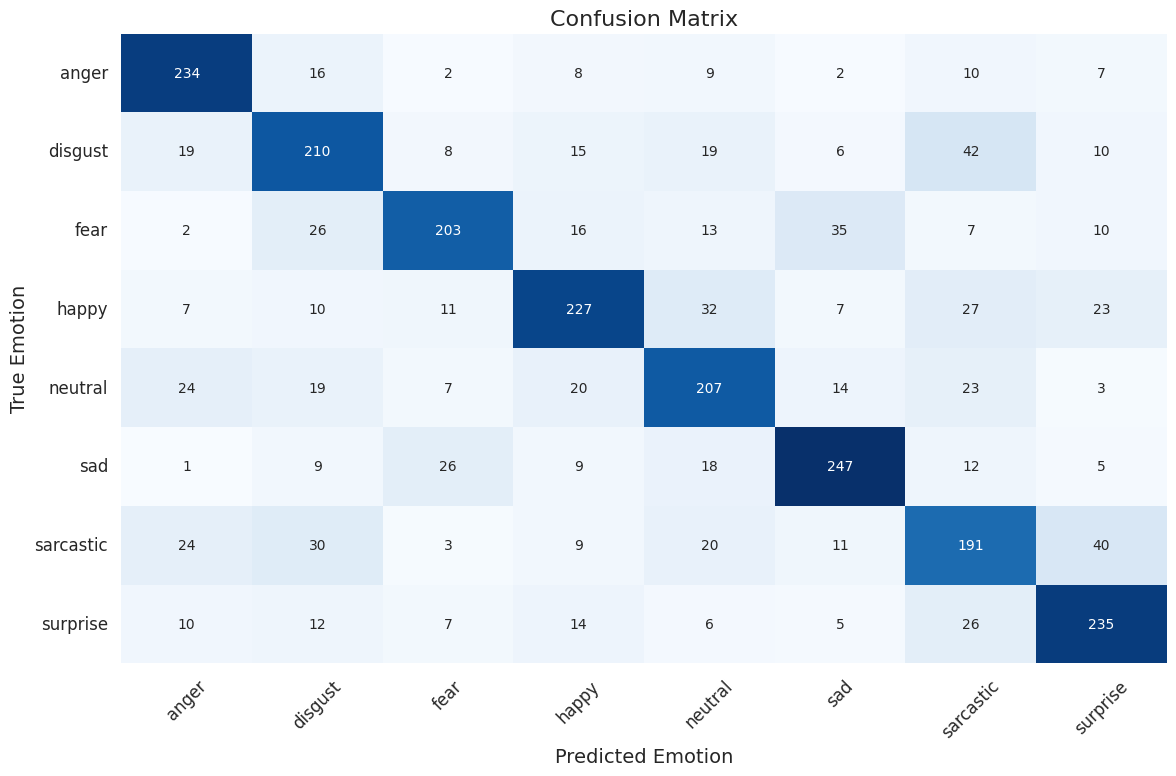

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(12, 8))
sns.set(font_scale=1.2)  # Adjust font size for better readability
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            annot_kws={"size": 10}, cbar=False)

# Add Labels and Title
plt.title('Confusion Matrix', fontsize=16)
plt.xlabel('Predicted Emotion', fontsize=14)
plt.ylabel('True Emotion', fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(rotation=0, fontsize=12)
plt.tight_layout()  # Adjust layout for better visualization
plt.show()